# Imports

In [1]:
%reload_ext autoreload
%autoreload 2


import pandas as pd
import os
import sys
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    PrecisionRecallDisplay,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt


sys.path.insert(
    0,
    os.path.join(
        os.path.dirname(os.path.abspath('')),
    )
)
from occam.ood_detection.uncertainty_scores import (
    div_continous_unique_per_sample,
    average_energy_per_sample,
    ens_entropy_per_sample,
    entropy,
    ens_conf_per_sample,
    get_probs
)
sys.path.pop(0)


from stuned.utility.utils import (
    append_dict,
    optionally_make_dir,
    get_project_root_path
)
from stuned.local_datasets.imagenet1k import get_imagenet_dataset
from stuned.local_datasets.transforms import (
    make_default_test_transforms_imagenet
)
from stuned.local_datasets.transforms import (
      make_default_test_transforms_imagenet,
)

# Functions

In [2]:
def plot_multiple_pr_curves(labels_scores, title, pr=True, log_scale=False, fontsize=12, save_path=None):
    f = plt.figure(figsize=(8, 6))  # Create a new figure
    ax = plt.gca()  # Get the current axis
    plot_chance_level = False
    i = 0

    # Iterate through the provided label and score pairs
    for labels, scores, name in labels_scores:
        if pr:
            if i + 1 == len(labels_scores):
                plot_chance_level = True
            display = PrecisionRecallDisplay.from_predictions(
                labels, scores, name=name, ax=ax, plot_chance_level=plot_chance_level
            )
            i += 1
        else:
            fpr, tpr, _ = roc_curve(labels,  scores)
            ax.plot(fpr, tpr, label=name)
    if not pr:
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="y = x 'Random'")

    # Set log scale if requested
    if log_scale:
        ax.set_xscale("log")  # Set x-axis to log scale
        ax.set_yscale("log")  # Optionally, set y-axis to log scale if needed

    if title is not None:
        ax.set_title(title)
    plt.legend(loc="best", fontsize=fontsize)  # Add a legend
    # Set font size for axes labels and tick labels
    if not pr:
        ax.set_xlabel("False Positive Rate" if not pr else "Recall", fontsize=fontsize)
        ax.set_ylabel("True Positive Rate" if not pr else "Precision", fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.show()
    if save_path is not None:
        f.savefig(save_path)
    return f


def eval_model_list_on_dataloader(model_list, dataloader, device, max_samples=None):

    res = {}
    res["is_main_object"] = []

    for model_id, model in model_list:
        model.eval()
        model.to(device)
        res[model_id] = []

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader)):
            if max_samples is not None and i == max_samples:
                break

            assert batch[0].shape[0] == 1, "Implemented only for batch size 1"
            applied_mask, is_main_object = batch[4], batch[5]
            # image, label, bbox, mask, applied_mask, is_main_object = batch
            applied_mask = applied_mask.to(device)
            is_main_object = is_main_object.to(device)
            for model_id, model in model_list:
                logits = model(applied_mask)
                res[model_id].append(logits)

            res["is_main_object"].append(is_main_object.item())
    return res


def compute_unc(res, label_key):

    unc_scores = {}

    model_ids = []
    for model_id in res.keys():
        if model_id == label_key:
            continue
        model_ids.append(model_id)

    labels = res[label_key]
    unc_scores[label_key] = labels
    num_samples = len(labels)
    for sample_id in tqdm(range(num_samples)):
        stacked_logits = None
        for model_id in model_ids:
            logits = res[model_id][sample_id]
            append_dict(
                unc_scores,
                {model_id: {"conf": get_probs(logits).max().item()}},
                allow_new_keys=True
            )

            append_dict(
                unc_scores,
                {model_id: {"entropy": [entropy(logits).item()]}},
                allow_new_keys=True
            )

            if stacked_logits is None:
                stacked_logits = logits.unsqueeze(0)
            else:
                stacked_logits = torch.cat([stacked_logits, logits.unsqueeze(0)], dim=0)
        append_dict(
            unc_scores,
            {"ensemble": {"PDS": [1 - div_continous_unique_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )
        append_dict(
            unc_scores,
            {"ensemble": {"energy": [1 - average_energy_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )
        append_dict(
            unc_scores,
            {"ensemble": {"ens_ent": [1 - ens_entropy_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )
        append_dict(
            unc_scores,
            {"ensemble": {"ens_conf": [ens_conf_per_sample(stacked_logits).item()]}},
            allow_new_keys=True
        )

    return unc_scores


def clean_from_nan(main_object_values, entropy_values):
    res_main_object = []
    res_ent = []
    for i in range(len(entropy_values)):
        if not np.isnan(entropy_values[i][0]):
            res_ent.append(entropy_values[i][0])
            res_main_object.append(main_object_values[i])
    return res_main_object, res_ent


def print_roc_auc_scores(model_names, unc_scores, iou_results, oracle_results):

    for model_id in model_names:
        print(f"{model_id} conf:", roc_auc_score(unc_scores["is_main_object"], unc_scores[model_id]["conf"]))

    for model_id in model_names:
        main_object_values = unc_scores["is_main_object"]
        entropy_values = unc_scores[model_id]["entropy"]
        res_main_object, res_ent = clean_from_nan(main_object_values, entropy_values)
        print(f"{model_id} entropy:", roc_auc_score(res_main_object, res_ent))

    print("Energy:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["energy"]))
    print("PDS:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["PDS"]))
    print("ens_ent:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["ens_ent"]))
    print("ens_conf:", roc_auc_score(unc_scores["is_main_object"], unc_scores['ensemble']["ens_conf"]))
    print("Oracle:", roc_auc_score(iou_results, oracle_results))


def extract_foreground_score(parquet_column):
    res = []
    for oracle_value in tqdm(parquet_column):
        for key, value in oracle_value.items():
            if value is not None:
                fg_score_value = float(value['foreground_score'])
                res.append(fg_score_value)
                break
    return res

# OOD det

## Preparing dataloader

In [11]:
bboxed_dataset_config_oracle = {

    "csv_path": get_project_root_path() + "/data/csvs/cropformer/source_in_val_cropformer.parquet",
    "dataset_task": "detection",
    "eval_transform": make_default_test_transforms_imagenet(),
    "train_transform": None,
    "train_val_split": 0.0,
    "foreground_keyword": "oracle---clip_openai_ViT-L/14" # oracle field
}
# 4m30s

In [3]:
parquet_path = os.path.join(get_project_root_path(), "data", "csvs", "cropformer", "source_in_val_by_mask_size+by_background+by_num_connected_components.parquet")

In [4]:
# parquet = pd.read_parquet(bboxed_dataset_config_oracle["csv_path"])
parquet = pd.read_parquet(parquet_path)
# 5m16s


In [5]:
oracle_results = extract_foreground_score(parquet["oracle---clip_openai_ViT-L/14_metadata"])

100%|██████████| 407252/407252 [00:01<00:00, 367495.69it/s]


In [6]:
oracle_path = get_project_root_path() + "/data/results/ood_detection/oracle_results.pkl"
optionally_make_dir(oracle_path)
torch.save(oracle_results, oracle_path)

In [7]:
iou_results = []
for iou_value in tqdm(parquet["bbox_iou_label"]):
    iou_results.append(int(iou_value))

100%|██████████| 407252/407252 [00:00<00:00, 3155535.49it/s]


In [8]:
iou_path = get_project_root_path() + "/data/results/ood_detection/iou_results.pkl"
optionally_make_dir(iou_path)
torch.save(iou_results, iou_path)

## CLIP confidences

In [3]:
unc_scores_path_clips_filtered = os.path.join(get_project_root_path(), "data", "results", "uncertainty_scores", "5clips_ensemble_with_filter_unc_scores.pkl")
oracle_results = torch.load(get_project_root_path() + "/data/results/ood_detection/oracle_results.pkl")
iou_results = torch.load(get_project_root_path() + "/data/results/ood_detection/iou_results.pkl")
unc_scores_clips_filtered = torch.load(unc_scores_path_clips_filtered)
# takes about 30s

In [4]:
model_names_clips = [
    "clip_openclip_datacomp_xl_s13b_b90k_ViT-L-14",
    "clip_openclip_dfn2b_ViT-L-14-quickgelu",
    "clip_openclip_openai_ViT-L-14",
    "clip_openclip_laion400m_e31_ViT-L-14",
    "clip_openclip_laion400m_e32_ViT-L-14"
]

print_roc_auc_scores(
    model_names_clips,
    unc_scores_clips_filtered,
    iou_results=iou_results,
    oracle_results=oracle_results
)

clip_openclip_datacomp_xl_s13b_b90k_ViT-L-14 conf: 0.830293821824171
clip_openclip_dfn2b_ViT-L-14-quickgelu conf: 0.8392931990871505
clip_openclip_openai_ViT-L-14 conf: 0.8732168838030756
clip_openclip_laion400m_e31_ViT-L-14 conf: 0.7732581034327712
clip_openclip_laion400m_e32_ViT-L-14 conf: 0.7733738359831475
clip_openclip_datacomp_xl_s13b_b90k_ViT-L-14 entropy: 0.602618871321462
clip_openclip_dfn2b_ViT-L-14-quickgelu entropy: 0.7036844634345333
clip_openclip_openai_ViT-L-14 entropy: 0.8363945658625439
clip_openclip_laion400m_e31_ViT-L-14 entropy: 0.6174046422682468
clip_openclip_laion400m_e32_ViT-L-14 entropy: 0.6130485521910152
Energy: 0.8194685082061219
PDS: 0.8563282362462074
ens_ent: 0.8963447760260075
ens_conf: 0.8569492625863455
Oracle: 0.9005086714916559


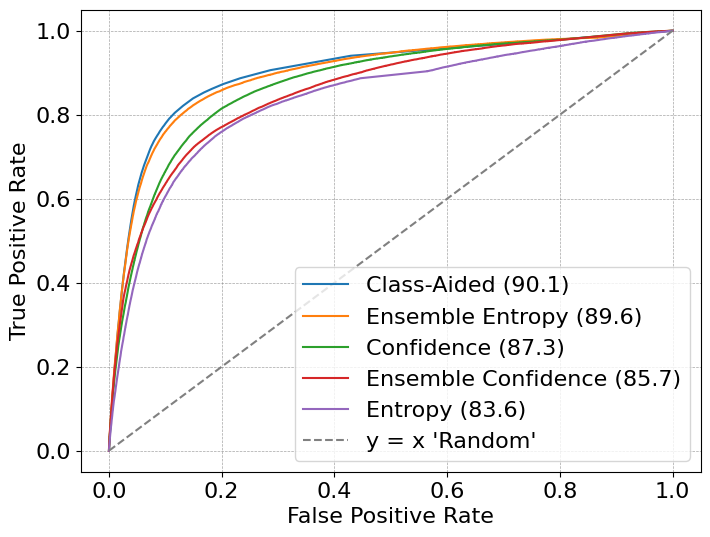

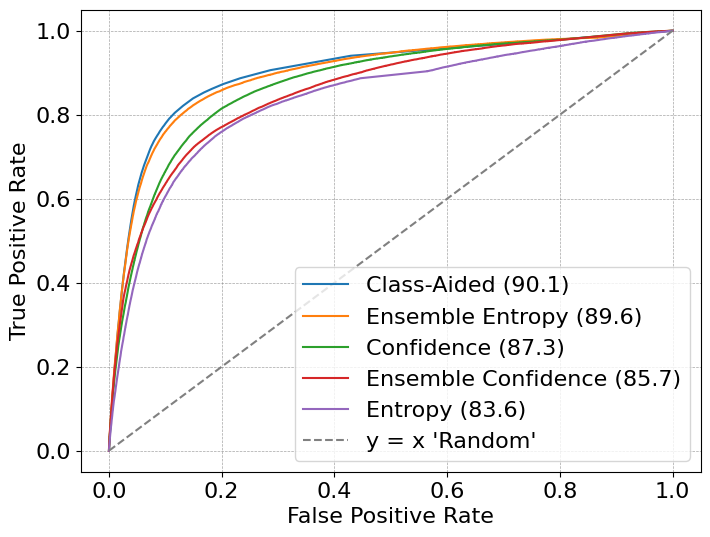

In [5]:
single_model_key = "clip_openclip_openai_ViT-L-14" # might change because we previously used dfn pre-trained
main_object_values = unc_scores_clips_filtered["is_main_object"]
entropy_values = unc_scores_clips_filtered[single_model_key]["entropy"]
res_main_object, res_ent = clean_from_nan(main_object_values, entropy_values)

plot_multiple_pr_curves(
    [
        (
            iou_results,
            oracle_results,
            "Class-Aided (90.1)"
        ),
        (
            unc_scores_clips_filtered["is_main_object"],
            unc_scores_clips_filtered['ensemble']["ens_ent"],
            "Ensemble Entropy (89.6)"
        ),
        (
            unc_scores_clips_filtered["is_main_object"],
            unc_scores_clips_filtered[single_model_key]["conf"],
            "Confidence (87.3)"
        ),
        (
            unc_scores_clips_filtered["is_main_object"],
            unc_scores_clips_filtered['ensemble']["ens_conf"],
            "Ensemble Confidence (85.7)"
        ),
        (
            res_main_object,
            res_ent,
            "Entropy (83.6)",
        ),
    ],
    # "ROC curves",
    pr=False,
    fontsize=16,
    title=None,
)